In [ ]:
import pandas as pd

# Column names for the Boston Housing dataset (no header row in the raw file)
columns = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
           "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]

df = pd.read_csv("4) house Prediction Data Set.csv", header=None, names=columns, sep=r"\s+")

print(df.shape)
df.head()

(506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
# Check for missing values
print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [ ]:
# Quick check: does RM correlate with MEDV?
print(df[["RM", "MEDV"]].corr())

           RM     MEDV
RM    1.00000  0.69536
MEDV  0.69536  1.00000


In [ ]:
from sklearn.model_selection import train_test_split

# Define our feature (X) and target (y)
X = df[["RM"]]   # double brackets keep it as a DataFrame, not a Series
y = df["MEDV"]

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (404, 1)
Testing set size: (102, 1)


In [ ]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train it on the training data
model.fit(X_train, y_train)

# Look at what it learned
print("Intercept:", model.intercept_)
print("Coefficient (slope):", model.coef_[0])

Intercept: -36.24631889813795
Coefficient (slope): 9.348301406497727


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 46.144775347317264
R-squared: 0.3707569232254778


In [ ]:
# Use ALL features instead of just RM
X_all = df.drop(columns=["MEDV"])  # everything except the target
y_all = df["MEDV"]

# Split again, same way as before
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

# Train a new model on all features
model_all = LinearRegression()
model_all.fit(X_train_all, y_train_all)

# Predict and evaluate
y_pred_all = model_all.predict(X_test_all)
mse_all = mean_squared_error(y_test_all, y_pred_all)
r2_all = r2_score(y_test_all, y_pred_all)

print("Multiple Regression — MSE:", mse_all)
print("Multiple Regression — R²:", r2_all)

Multiple Regression — MSE: 24.291119474973478
Multiple Regression — R²: 0.6687594935356326


In [ ]:
# Load the full stock dataset
stock_df = pd.read_csv("2) Stock Prices Data Set.csv")

print(stock_df.shape)
stock_df.head()

(497472, 7)


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [ ]:
# Filter to just Apple (AAPL) stock
apple_df = stock_df[stock_df["symbol"] == "AAPL"].copy()

# Convert date column to proper datetime, then sort chronologically
apple_df["date"] = pd.to_datetime(apple_df["date"])
apple_df = apple_df.sort_values("date")

print(apple_df.shape)
apple_df.head()

(1007, 7)


,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


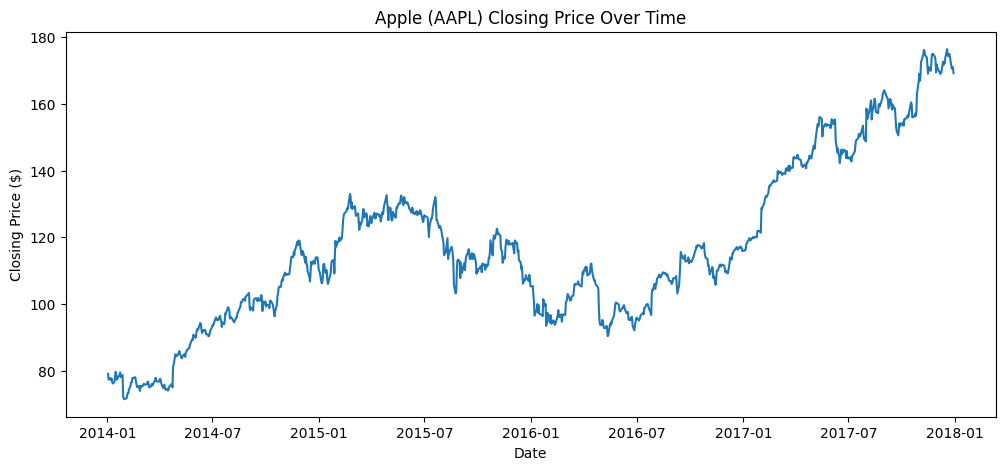

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(apple_df["date"], apple_df["close"])
plt.title("Apple (AAPL) Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.show()

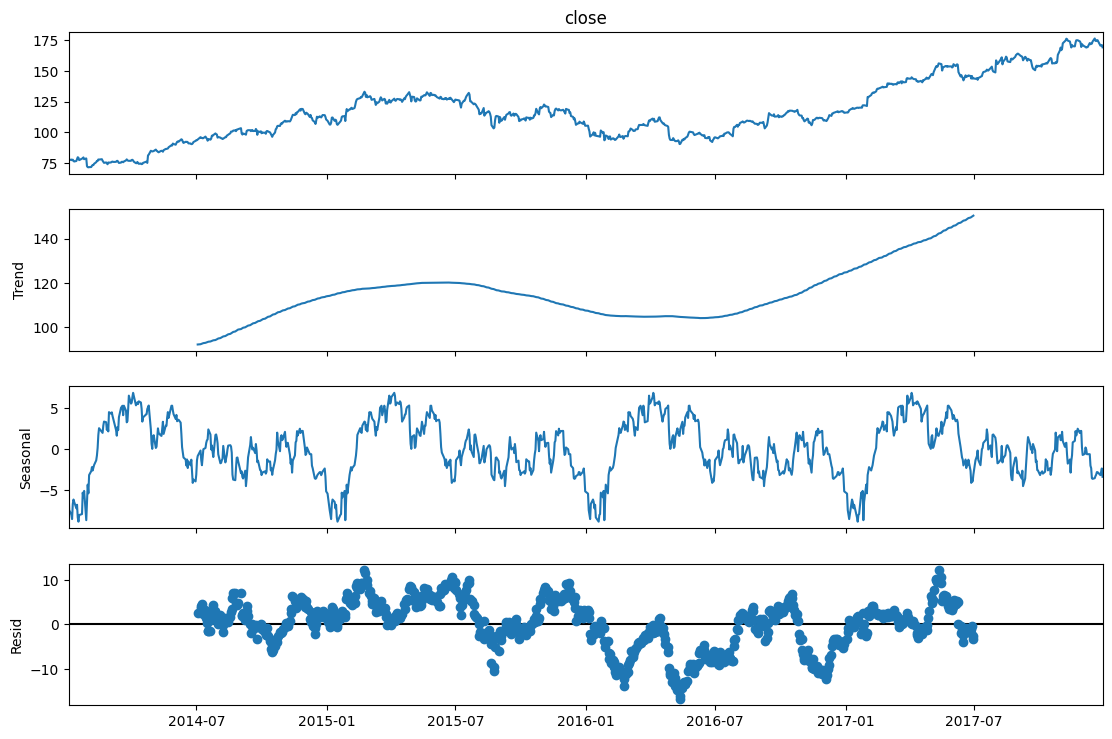

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set date as the index (required for time series decomposition)
apple_ts = apple_df.set_index("date")["close"]

# Decompose: period=252 approximates one trading year (252 trading days/year)
decomposition = seasonal_decompose(apple_ts, model="additive", period=252)

# Plot all components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

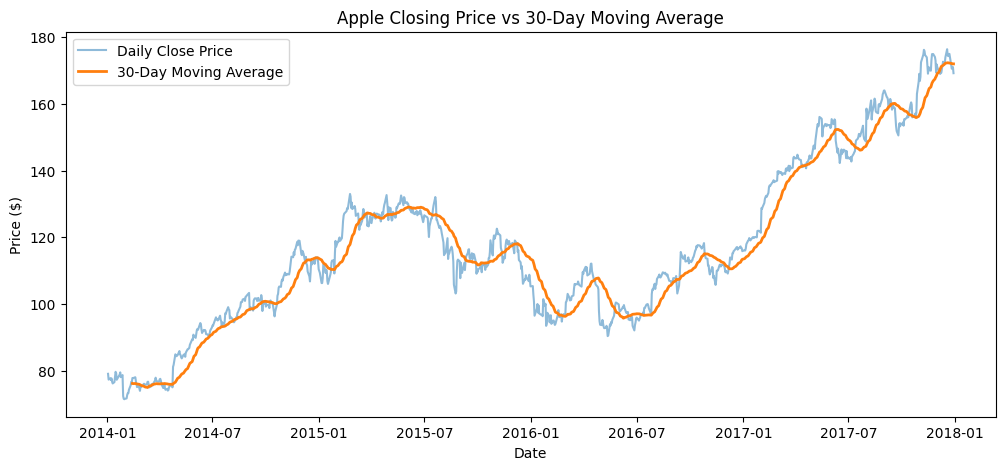

In [ ]:
# Calculate a 30-day moving average
apple_df["MA_30"] = apple_df["close"].rolling(window=30).mean()

# Plot original price vs the smoothed moving average
plt.figure(figsize=(12, 5))
plt.plot(apple_df["date"], apple_df["close"], label="Daily Close Price", alpha=0.5)
plt.plot(apple_df["date"], apple_df["MA_30"], label="30-Day Moving Average", linewidth=2)
plt.title("Apple Closing Price vs 30-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()